Este Notebook pretende servir de apoyo tanto a lo visto en clase:
- https://pradogrado2526.ugr.es/pluginfile.php/243157/mod_folder/content/0/2.3.Pyramids.pdf
- https://pradogrado2526.ugr.es/pluginfile.php/243157/mod_folder/content/0/2.3.FourierAnalysis_in_Images.pptx
- https://pradogrado2526.ugr.es/pluginfile.php/243157/mod_folder/content/0/2_dudas.pdf

Como a lo visto en algunos de los principales materiales empleados como referencia para este bloque:

- https://www.cs.unm.edu/~brayer/vision/fourier.html

- https://web.archive.org/web/20130513181427id_/http://sharp.bu.edu/~slehar/fourier/fourier.html

- https://www.youtube.com/watch?v=tEzgtbnbXgQ ("Fourier Transform | Image Processing II" de Shree Nayar)



Resulta fundamental remarcar que la visualización de la imagen de Fourier es un elemento clave. Es decir, el mismo resultado de la Transformada de Fourier (TF) visualizado de un modo u otro, empleando un mapa de color u otro diferente, puede variar enormemente. De modo que, si el resultado de una TF no se corresponde exactamente con lo que esperáis ver, no dudéis en darle una vuelta a la visualización.

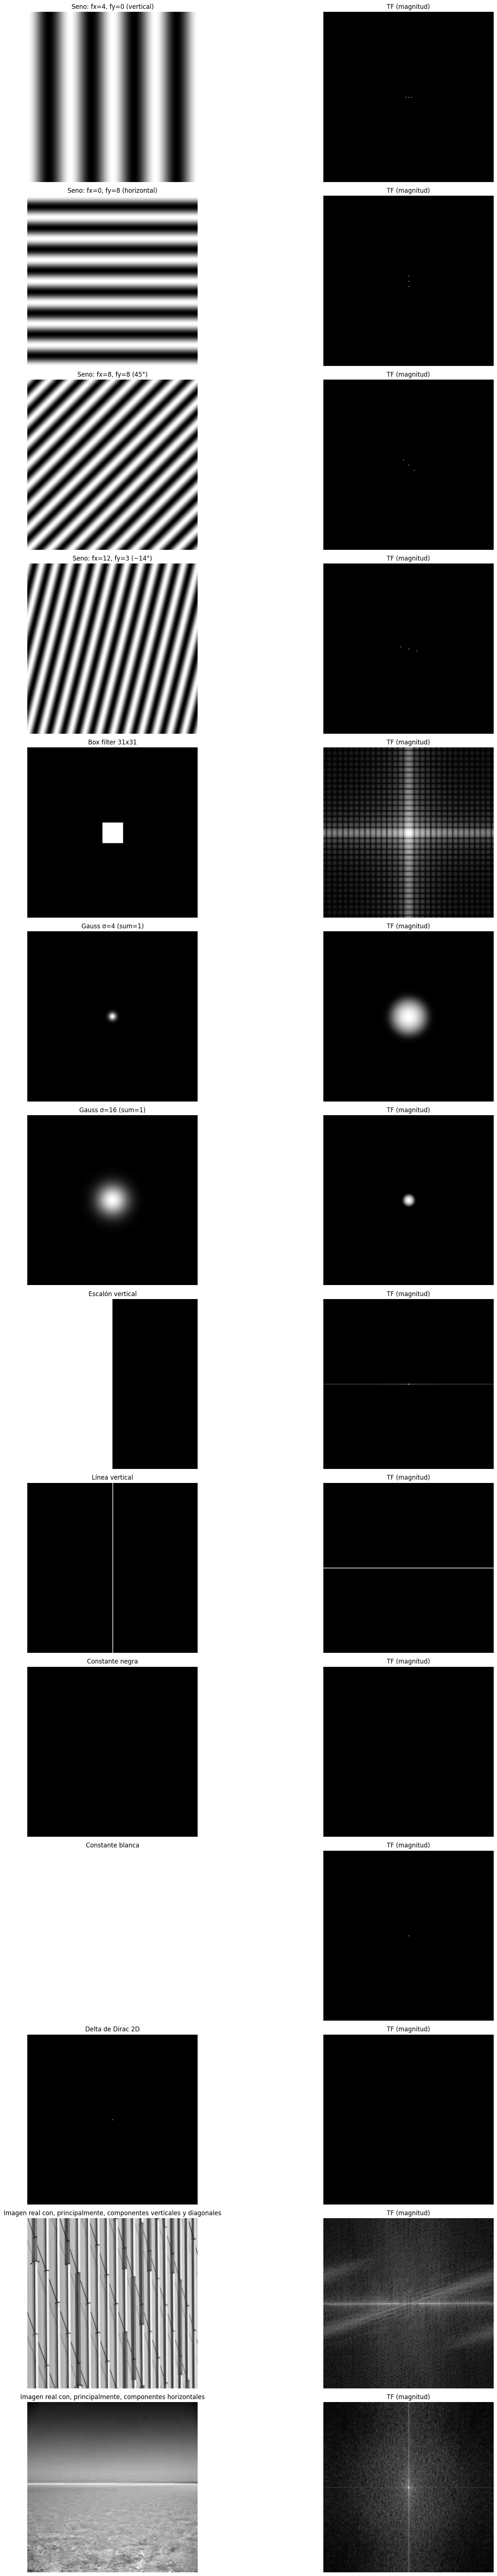

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio
import cv2

def fft_mag(img):
    """Módulo de la TF 2D, centrada y en log para visualización."""
    F = np.fft.fft2(img)
    F = np.fft.fftshift(F)
    mag = np.log1p(np.abs(F))
    return mag

def norm01(a):
    """Normalizamos en el intervalo [0,1]."""
    a = a.astype(np.float64)
    mn, mx = a.min(), a.max()
    return (a - mn) / (mx - mn + 1e-12)

def sinusoid(H, W, fx, fy, phase=0.0):
    """Sinusoide con las frecuencias y fase que nos interesen."""
    y, x = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
    arg = 2*np.pi*(fx*x/W + fy*y/H) + phase
    s = np.cos(arg)
    return norm01(s)

def gaussian2d(H, W, sigma, x0=None, y0=None):
    """Gaussiana isotrópica 2D."""
    if x0 is None: x0 = (W-1)/2
    if y0 is None: y0 = (H-1)/2
    y, x = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
    G = np.exp(-((x-x0)**2 + (y-y0)**2)/(2*sigma**2))
    # G /= G.sum()
    # Quitamos esta normalización solamente por motivos de visualización. Al fijar "vmin=0, vmax=1" más abajo estoy
    # forzando un rango mucho mayor que los valores reales de este kernel normalizado por suma = 1. Como consecuencia, los valores de la imagen original, en el dominio del espacio, se ven muy oscuros en el plot.
    return G

def box_filter(H, W, k):
    """Box filter 2D."""
    B = np.zeros((H, W), np.float64)
    cy, cx = H//2, W//2
    r = k//2
    B[cy-r:cy+r+1, cx-r:cx+r+1] = 1.0
    # B /= B.sum()
    # Quitamos esta normalización solamente por motivos de visualización. Al fijar "vmin=0, vmax=1" más abajo estoy
    # forzando un rango mucho mayor que los valores reales de este kernel normalizado por suma = 1. Como consecuencia, los valores de la imagen original, en el dominio del espacio, se ven muy oscuros en el plot.
    return B

def vertical_step(H, W):
    """Escalón vertical."""
    img = np.zeros((H, W), np.float64)
    img[:, :W//2] = 1.0
    return img

def dirac2d(H, W):
    """
    Impulso unitario 2D (delta discreta).
    """
    # Cuidado con este caso: la delta produce una magnitud uniforme en todo el espectro (https://links.uwaterloo.ca/amath353docs/set11.pdf)
    # Abajo vemos su TF todo negro, pero si hiciésemos plt.imshow(mag, cmap="gray", vmin=0, vmax=1) veríamos todo gris, dado que mag = log1p(1) = log(2) ≈ 0.693
    # De nuevo, debemos ser cuidadosos con la visualización
    img = np.zeros((H, W), np.float64)
    y = H//2
    x = W//2
    img[y, x] = 1.0
    return img

def vertical_step_derivative(H, W):
    """
    Derivada discreta del escalón vertical ≈ delta en x: una línea vertical de 1 px en la columna del borde.
    """
    img = np.zeros((H, W), np.float64)
    img[:, W//2] = 1.0  # impulso vertical
    return img

def fetch_and_prepare(url, H=256, W=256):
    """Función para descargar imágenes y probar con ellas."""
    img = iio.imread(url)
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    img = img.astype(np.float32)
    img = cv2.resize(img, (W, H), interpolation=cv2.INTER_AREA)
    return norm01(img)

# ---------- generamos los casos que nos interesan----------
H = W = 256

cases = []

# Sinusoides
cases.append(("Seno: fx=4, fy=0 (vertical)", sinusoid(H,W, fx=4, fy=0)))
cases.append(("Seno: fx=0, fy=8 (horizontal)", sinusoid(H,W, fx=0, fy=8)))
cases.append(("Seno: fx=8, fy=8 (45°)", sinusoid(H,W, fx=8, fy=8)))
cases.append(("Seno: fx=12, fy=3 (~14°)", sinusoid(H,W, fx=12, fy=3)))

# Box filter
cases.append((f"Box filter {31}x{31}", box_filter(H,W, k=31)))

# Gaussianas con dos sigmas
cases.append(("Gauss σ=4 (sum=1)", gaussian2d(H,W, sigma=4)))
cases.append(("Gauss σ=16 (sum=1)", gaussian2d(H,W, sigma=16)))

# Escalón vertical
cases.append(("Escalón vertical", vertical_step(H,W)))

# Línea vertical
cases.append(("Línea vertical", vertical_step_derivative(H,W)))

# Imagen constante negra
cases.append(("Constante negra", np.zeros((H, W), np.float64)))

# Imagen constante blanca
cases.append(("Constante blanca", np.ones((H, W), np.float64)))

# Dirac 2D
cases.append(("Delta de Dirac 2D", dirac2d(H, W)))

# Imagen web con componentes principalmente verticales
# (fachada con muchas líneas verticales y diagonales)
url_vert = "https://freerangestock.com/sample/185291/sleek-vertical-lines-of-a-modern-high-rise-building-facade..jpg"

# Imagen web con componentes principalmente horizontales
# (paisaje con horizonte)
url_horiz = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRpdMyaVWeF7oI3pRqsCDCLVuKmklou0GcgQw&s"

cases.append(("Imagen real con, principalmente, componentes verticales y diagonales", fetch_and_prepare(url_vert, H, W)))

cases.append(("Imagen real con, principalmente, componentes horizontales", fetch_and_prepare(url_horiz, H, W)))


# ---------- visualización ----------
rows = len(cases)
plt.figure(figsize=(20, 5*rows))
for i, (title, img) in enumerate(cases, 1):
    mag = fft_mag(img)

    plt.subplot(rows, 2, 2*i-1)
    plt.imshow(img, cmap="gray", vmin=0, vmax=1) # Añado "vmin=0, vmax=1" porque, imshow autoescala cada imagen con vmin=min(img) y vmax=max(img), y en el caso de la imagen completamente blanca muestra una imagen en negro (lo que lleva a confusiones)
                                                 # Si la imagen es constante blanca (todo 1), entonces min=max=1 → el rango es 0, así que Matplotlib la pinta negra (equivale a todo 0 tras la normalización).
    plt.title(title); plt.axis("off")

    plt.subplot(rows, 2, 2*i)
    plt.imshow(mag, cmap="gray")
    plt.title("TF (magnitud)"); plt.axis("off")

plt.tight_layout()
plt.show()


A continuación, vamos a hacer un ejercicio práctico en donde, a partir de la TF de una imagen, podemos reconstruirla sin pérdida empleando la TF inversa.

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import matplotlib.pyplot as plt
import numpy as np
import cv2
import os,sys

Mounted at /content/drive


In [3]:
get_image = lambda route: os.path.join('/content/drive/My Drive/images', route)

image=cv2.imread(get_image('zebra.jpg'),0)/255

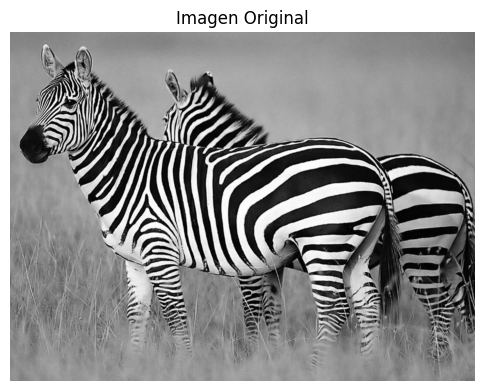

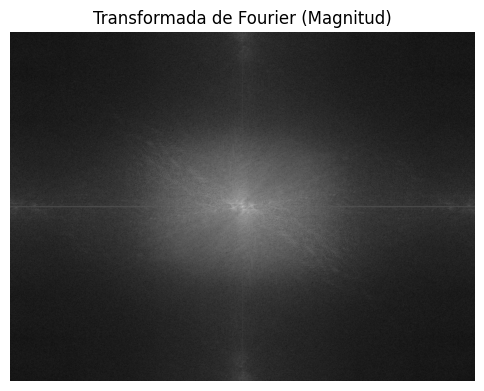

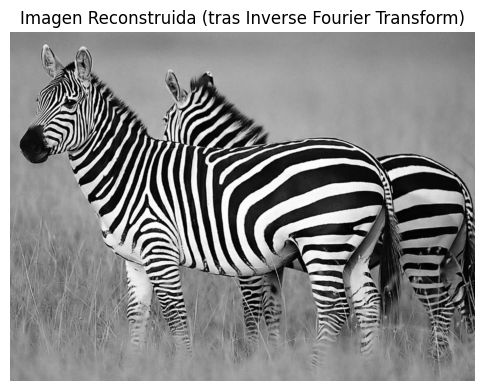

MSE entre original y reconstruida: 0.0


In [4]:
from skimage.metrics import mean_squared_error as mse

img = image.copy()

# Mostramos la imagen original
plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title("Imagen Original")
plt.axis('off')
plt.show()

# Aplicamos TF a la imagen
img_fft = np.fft.fft2(img)
img_fft_shifted = np.fft.fftshift(img_fft)

# Mostramos la magnitud de la TF
magnitude_spectrum = np.log(np.abs(img_fft_shifted) + 1)
plt.figure(figsize=(6,6))
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Transformada de Fourier (Magnitud)")
plt.axis('off')
plt.show()

# Aplicamos IFT
img_ifft_shifted = np.fft.ifftshift(img_fft_shifted)
img_reconstructed = np.fft.ifft2(img_ifft_shifted)
img_reconstructed = np.abs(img_reconstructed)

# Mostramos la imagen reconstruida
plt.figure(figsize=(6,6))
plt.imshow(img_reconstructed, cmap='gray')
plt.title("Imagen Reconstruida (tras Inverse Fourier Transform)")
plt.axis('off')
plt.show()

# Calculamos MSE
error = mse(np.round(img), np.round(img_reconstructed))
print(f"MSE entre original y reconstruida: {error}")

